# Problem 5 — Fresh PyTorch image classifier
Reference: Géron (2025), Chapter 10, ‘Building an Image Classifier with PyTorch’, cells 111–132; helpers 85, 91, 93 and 20 epochs from cell 63.

Preserved: scaled float32 images, seeded 55,000/5,000 split, batch size 32, 784→300→100→10 ReLU MLP, cross-entropy, SGD learning rate 0.1, 20 epochs. Deviations: deterministic CPU with two threads for portable execution; direct correct/total accuracy replaces TorchMetrics equivalently; evaluation loss is sample-weighted. Training loss retains the reference batch mean, and training accuracy measures predictions during updates. Added held-out test evaluation and plots. No earlier classifier implementation was used.

## 01_setup.py

In [1]:
import os, sys, json, time, random, platform
from pathlib import Path
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms.v2 as T
import matplotlib.pyplot as plt
from IPython.display import display
assert sys.version_info >= (3, 10)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(2)
torch.use_deterministic_algorithms(True)
device = torch.device("cpu")
n_epochs = 20
ARTIFACTS = Path("artifacts")
ARTIFACTS.mkdir(exist_ok=True)
versions = {"python": platform.python_version(), "torch": torch.__version__, "torchvision": torchvision.__version__, "numpy": np.__version__, "device": str(device)}
print(versions)


2026-09-26 11:48:05.514 system_profiler[10320:442994] XType: Using static font registry.


Matplotlib is building the font cache; this may take a moment.


{'python': '3.12.14', 'torch': '2.8.0', 'torchvision': '0.23.0', 'numpy': '2.5.3', 'device': 'cpu'}


## 02_dataset.py

In [2]:
transform = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])
data_root = Path(os.environ.get("FASHION_MNIST_ROOT", "datasets"))
all_training = torchvision.datasets.FashionMNIST(data_root, train=True, download=True, transform=transform)
test_data = torchvision.datasets.FashionMNIST(data_root, train=False, download=True, transform=transform)
classes = all_training.classes
image, label = all_training[0]
assert image.shape == (1, 28, 28) and image.dtype == torch.float32
assert 0 <= image.min() <= image.max() <= 1
print("Image:", tuple(image.shape), image.dtype, "label:", classes[label])


Image: (1, 28, 28) torch.float32 label: Ankle boot


## 03_partition.py

In [3]:
torch.manual_seed(SEED)
train_data, valid_data = random_split(all_training, [55_000, 5_000])
assert len(test_data) == 10_000
assert set(train_data.indices).isdisjoint(valid_data.indices)
assert len(set(train_data.indices) | set(valid_data.indices)) == 60_000
print({"training": len(train_data), "validation": len(valid_data), "test": len(test_data)})


{'training': 55000, 'validation': 5000, 'test': 10000}


## 04_loaders.py

In [4]:
torch.manual_seed(SEED)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=0)
valid_loader = DataLoader(valid_data, batch_size=32, num_workers=0)
test_loader = DataLoader(test_data, batch_size=32, num_workers=0)
print("Batches:", len(train_loader), len(valid_loader), len(test_loader))


Batches: 1719 157 313


## 05_model.py

In [5]:
class ImageClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.mlp = nn.Sequential(nn.Flatten(), nn.Linear(784, 300), nn.ReLU(),
                                 nn.Linear(300, 100), nn.ReLU(), nn.Linear(100, 10))
    def forward(self, images):
        return self.mlp(images)

torch.manual_seed(SEED)
model = ImageClassifier().to(device)
parameter_count = sum(p.numel() for p in model.parameters())
assert parameter_count == 266610
print(model)
print("Parameters:", parameter_count)


ImageClassifier(
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=300, bias=True)
    (2): ReLU()
    (3): Linear(in_features=300, out_features=100, bias=True)
    (4): ReLU()
    (5): Linear(in_features=100, out_features=10, bias=True)
  )
)
Parameters: 266610


## 06_loss_optimizer.py

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
print(criterion, optimizer)


CrossEntropyLoss() SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.1
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)


## 07_helpers.py

In [7]:
def evaluate(model, loader):
    model.eval()
    total_loss, correct, count = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            total_loss += criterion(logits, labels).item() * len(labels)
            correct += (logits.argmax(1) == labels).sum().item()
            count += len(labels)
    return {"loss": total_loss / count, "accuracy": correct / count, "count": count}

def train_epoch(model, loader):
    model.train()
    batch_loss_sum, correct, count = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss = criterion(logits, labels)
        batch_loss_sum += loss.item()
        correct += (logits.argmax(1) == labels).sum().item()
        count += len(labels)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    return {"loss": batch_loss_sum / len(loader), "accuracy": correct / count, "count": count}


## 08_training.py

In [8]:
history = []
started = time.perf_counter()
for epoch in range(1, n_epochs + 1):
    training = train_epoch(model, train_loader)
    validation = evaluate(model, valid_loader)
    assert training["count"] == 55_000 and validation["count"] == 5_000
    row = {"epoch": epoch, "train_loss": training["loss"], "train_accuracy": training["accuracy"],
           "validation_loss": validation["loss"], "validation_accuracy": validation["accuracy"]}
    history.append(row)
    print(f"Epoch {epoch:02d}/{n_epochs}: train loss={row['train_loss']:.4f}, train accuracy={row['train_accuracy']:.4%}, validation accuracy={row['validation_accuracy']:.4%}", flush=True)
training_seconds = time.perf_counter() - started
assert len(history) == 20
(ARTIFACTS / "history.json").write_text(json.dumps(history, indent=2))
print(f"Full training time: {training_seconds:.2f} seconds")


Epoch 01/20: train loss=0.6060, train accuracy=78.1127%, validation accuracy=84.1200%


Epoch 02/20: train loss=0.4055, train accuracy=85.0145%, validation accuracy=84.6000%


Epoch 03/20: train loss=0.3626, train accuracy=86.6218%, validation accuracy=85.3600%


Epoch 04/20: train loss=0.3347, train accuracy=87.7473%, validation accuracy=86.1400%


Epoch 05/20: train loss=0.3144, train accuracy=88.4091%, validation accuracy=87.8400%


...

Epoch 17/20: train loss=0.2042, train accuracy=92.2455%, validation accuracy=88.2000%


Epoch 18/20: train loss=0.1999, train accuracy=92.3091%, validation accuracy=88.4600%


Epoch 19/20: train loss=0.1938, train accuracy=92.6091%, validation accuracy=87.6800%


Epoch 20/20: train loss=0.1878, train accuracy=92.7818%, validation accuracy=87.5200%


Full training time: 45.62 seconds


## 09_learning_curves.py

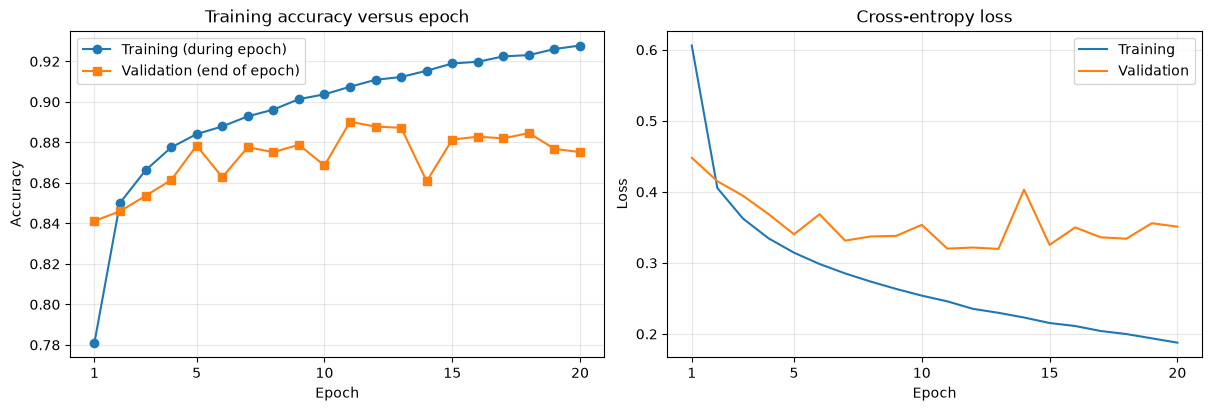

In [9]:
epochs = [row["epoch"] for row in history]
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].plot(epochs, [r["train_accuracy"] for r in history], "o-", label="Training (during epoch)")
axes[0].plot(epochs, [r["validation_accuracy"] for r in history], "s-", label="Validation (end of epoch)")
axes[0].set(title="Training accuracy versus epoch", xlabel="Epoch", ylabel="Accuracy")
axes[0].legend()
axes[1].plot(epochs, [r["train_loss"] for r in history], label="Training")
axes[1].plot(epochs, [r["validation_loss"] for r in history], label="Validation")
axes[1].set(title="Cross-entropy loss", xlabel="Epoch", ylabel="Loss")
axes[1].legend()
for ax in axes:
    ax.set_xticks([1, 5, 10, 15, 20])
    ax.grid(alpha=0.3)
fig.savefig(ARTIFACTS / "learning_curves.png", dpi=160)
plt.show()
plt.close(fig)


## 10_predictions_test.py

Predicted: ['Sneaker', 'Coat', 'Pullover']


Actual: ['Sneaker', 'Coat', 'Pullover']


Full class probabilities: tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.8090, 0.0000,
         0.1900],
        [0.0000, 0.0000, 0.0060, 0.0000, 0.9940, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0030, 0.0000, 0.6490, 0.0010, 0.1520, 0.0000, 0.1960, 0.0000, 0.0000,
         0.0000]])
Top four indices: tensor([[7, 9, 5, 8],
        [4, 2, 6, 0],
        [2, 6, 4, 0]])
Softmax conditional on top four (as in reference): tensor([[0.8100, 0.1900, 0.0000, 0.0000],
        [0.9940, 0.0060, 0.0000, 0.0000],
        [0.6490, 0.1960, 0.1520, 0.0030]])


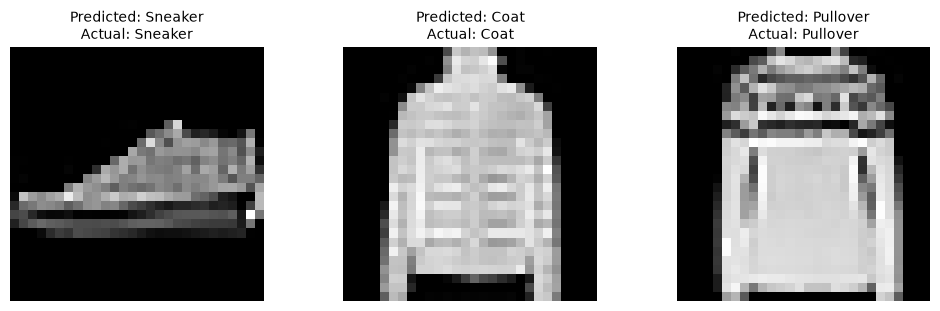

{
  "versions": {
    "python": "3.12.14",
    "torch": "2.8.0",
    "torchvision": "0.23.0",
    "numpy": "2.5.3",
    "device": "cpu"
  },
  "seed": 42,
  "epochs": 20,
  "parameters": 266610,
  "training_seconds": 45.62181849999979,
  "final_epoch": {
    "epoch": 20,
    "train_loss": 0.1877678490410179,
    "train_accuracy": 0.9278181818181818,
    "validation_loss": 0.3510256330013275,
    "validation_accuracy": 0.8752
  },
  "test": {
    "loss": 0.3664569815278053,
    "accuracy": 0.8775,
    "count": 10000
  },
  "predicted_labels": [
    7,
    4,
    2
  ],
  "actual_labels": [
    7,
    4,
    2
  ]
}


In [10]:
model.eval()
images, labels = next(iter(valid_loader))
with torch.no_grad():
    logits = model(images[:3].to(device))
    probabilities = logits.softmax(dim=1).cpu()
predictions = logits.argmax(1).cpu()
top4_values, top4_indices = logits.topk(4, dim=1)
print("Predicted:", [classes[i] for i in predictions])
print("Actual:", [classes[i] for i in labels[:3]])
print("Full class probabilities:", probabilities.round(decimals=3))
print("Top four indices:", top4_indices.cpu())
print("Softmax conditional on top four (as in reference):", top4_values.softmax(1).cpu().round(decimals=3))
assert torch.allclose(probabilities.sum(1), torch.ones(3))
fig, axes = plt.subplots(1, 3, figsize=(10, 3), constrained_layout=True)
for i, ax in enumerate(axes):
    ax.imshow(images[i, 0], cmap="gray")
    ax.set_title(f"Predicted: {classes[predictions[i]]}\nActual: {classes[labels[i]]}", fontsize=10)
    ax.axis("off")
fig.savefig(ARTIFACTS / "predictions.png", dpi=160)
plt.show()
plt.close(fig)
test_metrics = evaluate(model, test_loader)
assert test_metrics["count"] == 10_000
results = {"versions": versions, "seed": SEED, "epochs": n_epochs, "parameters": parameter_count,
           "training_seconds": training_seconds, "final_epoch": history[-1], "test": test_metrics,
           "predicted_labels": predictions.tolist(), "actual_labels": labels[:3].tolist()}
(ARTIFACTS / "results.json").write_text(json.dumps(results, indent=2))
print(json.dumps(results, indent=2))
